<a href="https://colab.research.google.com/github/Megh8py/synent-task6-customersegmentation-Megh_Chauhan/blob/main/task6_customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 6: Customer Segmentation
## Synent Technologies – Data Science Internship

**Dataset:** Mall Customer Segmentation Dataset  
**Objective:** Group customers based on behavior using K-Means Clustering  
**Tools:** Python, Pandas, Matplotlib, Seaborn, Scikit-learn

## 1. Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Load Dataset


In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.
Path to dataset files: /kaggle/input/customer-segmentation-tutorial-in-python


In [7]:
df = pd.read_csv(path+'/Mall_Customers.csv')
print(f'Dataset Shape: {df.shape}')
df.head(10)

Dataset Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


## 3. Data Preprocessing

In [8]:
# Basic Info
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [9]:
# Summary statistics
print('=== Summary Statistics ===')
df.describe()

=== Summary Statistics ===


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [10]:
# Check missing values
print('=== Missing Values ===')
print(df.isnull().sum())

# Check duplicates
print(f'\nDuplicate rows: {df.duplicated().sum()}')

=== Missing Values ===
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate rows: 0


In [12]:
# Rename columns for clarity
df.rename(columns={
    'CustomerID': 'customer_id',
    'Gender': 'gender',
    'Age': 'age',
    'Annual Income (k$)': 'annual_income',
    'Spending Score (1-100)': 'spending_score'
}, inplace=True)

# Encode gender
df['gender_encoded'] = df['gender'].map({'Male': 0, 'Female': 1})

print('Column names updated:')
print(df.columns.tolist())
df.head()

Column names updated:
['customer_id', 'gender', 'age', 'annual_income', 'spending_score', 'gender_encoded']


,customer_id,gender,age,annual_income,spending_score,gender_encoded
0,1,Male,19,15,39,0
1,2,Male,21,15,81,0
2,3,Female,20,16,6,1
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


## 4. Exploratory Data Analysis (EDA)

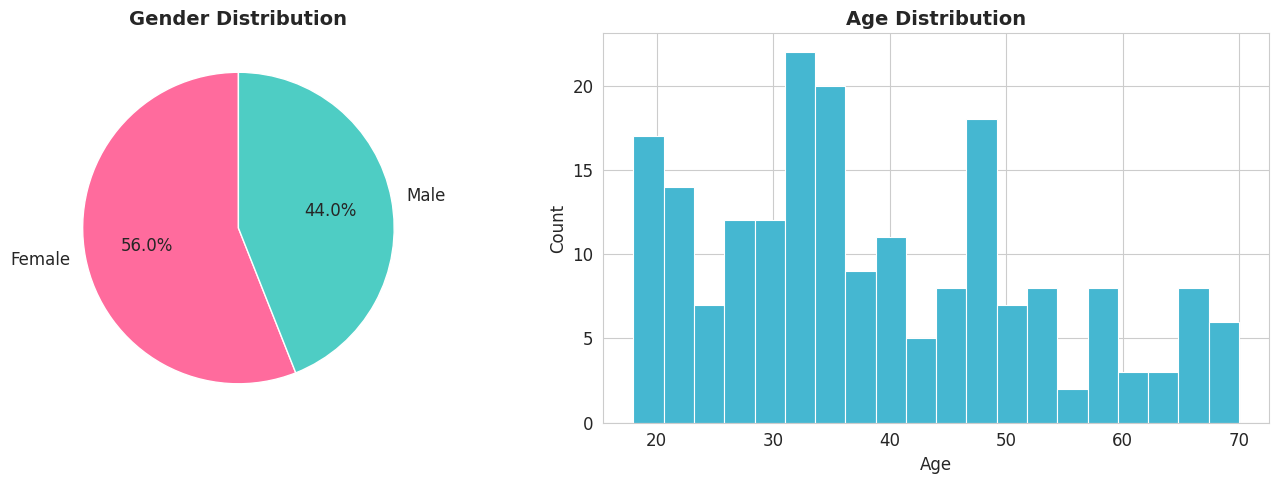

In [13]:
# Gender distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gender_counts = df['gender'].value_counts()
axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=['#FF6B9D', '#4ECDC4'], startangle=90)
axes[0].set_title('Gender Distribution', fontsize=14, fontweight='bold')

# Age distribution
axes[1].hist(df['age'], bins=20, color='#45B7D1', edgecolor='white', linewidth=0.8)
axes[1].set_title('Age Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

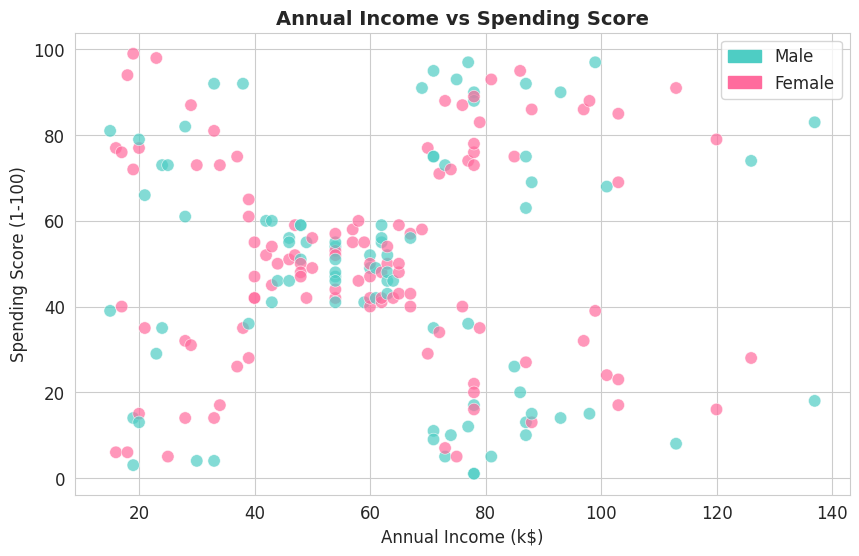

In [14]:
# Income vs Spending Score scatter
plt.figure(figsize=(10, 6))
colors = df['gender'].map({'Male': '#4ECDC4', 'Female': '#FF6B9D'})
plt.scatter(df['annual_income'], df['spending_score'], c=colors, alpha=0.7, s=80, edgecolors='white', linewidth=0.5)

male_patch = mpatches.Patch(color='#4ECDC4', label='Male')
female_patch = mpatches.Patch(color='#FF6B9D', label='Female')
plt.legend(handles=[male_patch, female_patch])

plt.title('Annual Income vs Spending Score', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.savefig('eda_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

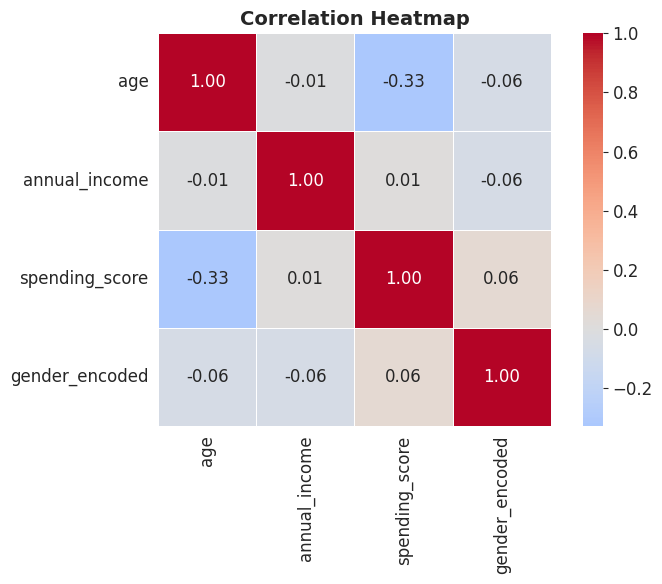

In [15]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
corr = df[['age', 'annual_income', 'spending_score', 'gender_encoded']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. K-Means Clustering

We cluster on **Annual Income** and **Spending Score** — the two most behaviorally meaningful features.

In [16]:
# Select features
X = df[['annual_income', 'spending_score']].values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Features selected: Annual Income, Spending Score')
print(f'Data shape: {X_scaled.shape}')

Features selected: Annual Income, Spending Score
Data shape: (200, 2)


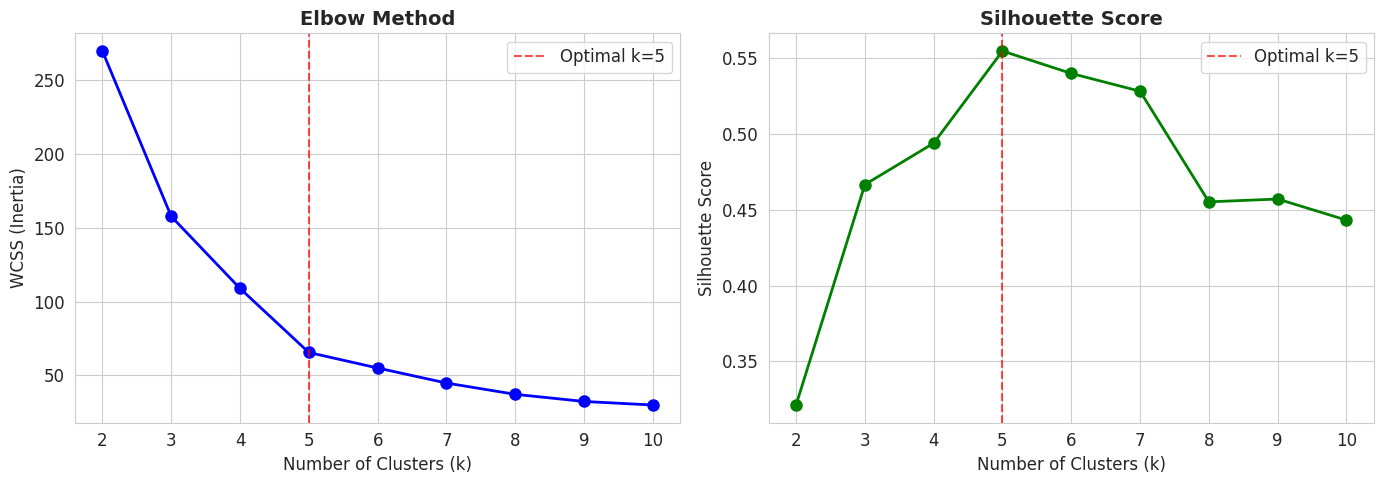


Best Silhouette Score: 0.5547 at k=5


In [17]:
# Elbow Method to find optimal k
wcss = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)

# Plot Elbow + Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, wcss, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=5, color='red', linestyle='--', alpha=0.7, label='Optimal k=5')
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('WCSS (Inertia)')
axes[0].legend()

axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].axvline(x=5, color='red', linestyle='--', alpha=0.7, label='Optimal k=5')
axes[1].set_title('Silhouette Score', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

optimal_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f'\nBest Silhouette Score: {max(silhouette_scores):.4f} at k={optimal_k}')

In [18]:
# Train final K-Means model with k=5
k_optimal = 5
kmeans = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(f'K-Means trained with k={k_optimal}')
print(f'Final Inertia: {kmeans.inertia_:.2f}')
print(f'Silhouette Score: {silhouette_score(X_scaled, df["cluster"]):.4f}')
print('\nCluster sizes:')
print(df['cluster'].value_counts().sort_index())

K-Means trained with k=5
Final Inertia: 65.57
Silhouette Score: 0.5547

Cluster sizes:
cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


## 6. Visualize Clusters

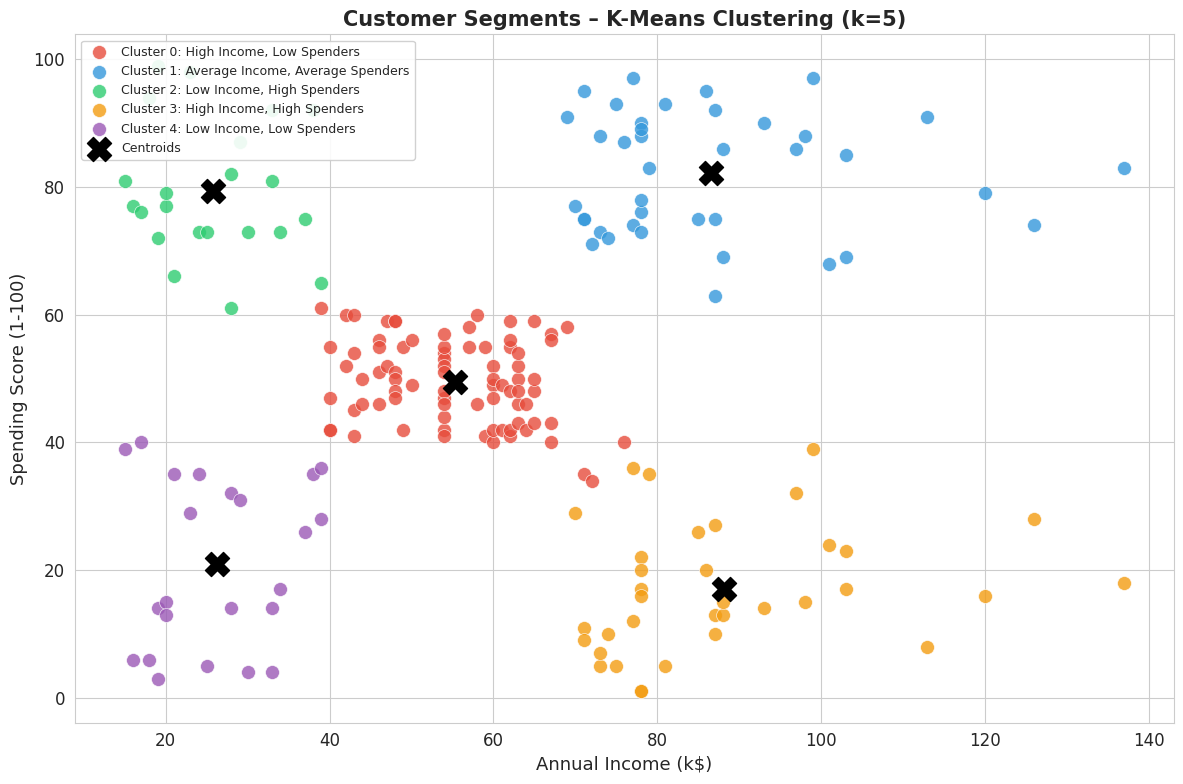

Cluster visualization saved!


In [19]:
# Cluster names based on typical mall segmentation findings
cluster_labels = {
    0: 'High Income, Low Spenders',
    1: 'Average Income, Average Spenders',
    2: 'Low Income, High Spenders',
    3: 'High Income, High Spenders',
    4: 'Low Income, Low Spenders'
}

colors_palette = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']

plt.figure(figsize=(12, 8))

for i in range(k_optimal):
    mask = df['cluster'] == i
    plt.scatter(df.loc[mask, 'annual_income'],
                df.loc[mask, 'spending_score'],
                c=colors_palette[i], label=f'Cluster {i}: {cluster_labels[i]}',
                s=100, alpha=0.8, edgecolors='white', linewidth=0.5)

# Plot centroids (inverse transform back to original scale)
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids_original[:, 0], centroids_original[:, 1],
            s=300, c='black', marker='X', zorder=5, label='Centroids')

plt.title('Customer Segments – K-Means Clustering (k=5)', fontsize=15, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=13)
plt.ylabel('Spending Score (1-100)', fontsize=13)
plt.legend(loc='upper left', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig('customer_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Cluster visualization saved!')

In [20]:
# Cluster profile comparison
cluster_summary = df.groupby('cluster').agg(
    count=('customer_id', 'count'),
    avg_age=('age', 'mean'),
    avg_income=('annual_income', 'mean'),
    avg_spending=('spending_score', 'mean'),
    pct_female=('gender_encoded', 'mean')
).round(2)

cluster_summary['label'] = cluster_summary.index.map(cluster_labels)
cluster_summary['pct_female'] = (cluster_summary['pct_female'] * 100).round(1)
print('=== Cluster Profiles ===')
cluster_summary

=== Cluster Profiles ===


,count,avg_age,avg_income,avg_spending,pct_female,label
cluster,,,,,,
0,81,42.72,55.30,49.52,59.0,"High Income, Low Spenders"
1,39,32.69,86.54,82.13,54.0,"Average Income, Average Spenders"
2,22,25.27,25.73,79.36,59.0,"Low Income, High Spenders"
3,35,41.11,88.20,17.11,46.0,"High Income, High Spenders"
4,23,45.22,26.30,20.91,61.0,"Low Income, Low Spenders"


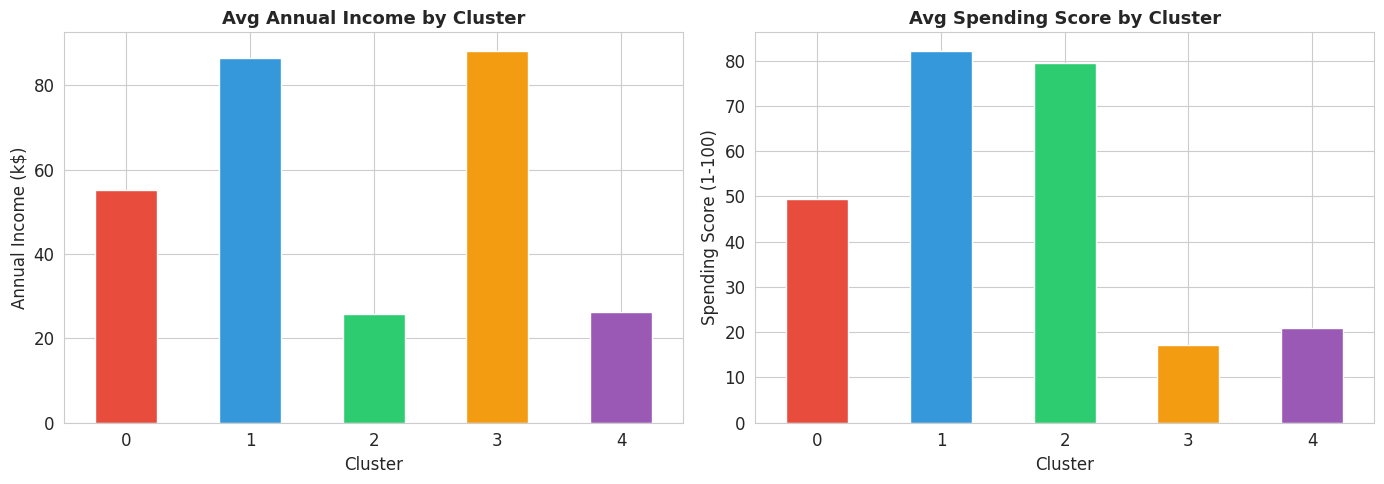

In [21]:
# Bar chart – avg income and spending per cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cluster_summary['avg_income'].plot(kind='bar', ax=axes[0], color=colors_palette, edgecolor='white')
axes[0].set_title('Avg Annual Income by Cluster', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Annual Income (k$)')
axes[0].tick_params(axis='x', rotation=0)

cluster_summary['avg_spending'].plot(kind='bar', ax=axes[1], color=colors_palette, edgecolor='white')
axes[1].set_title('Avg Spending Score by Cluster', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Spending Score (1-100)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Key Insights

| Cluster | Label | Key Trait | Business Strategy |
|---------|-------|-----------|-------------------|
| 0 | High Income, Low Spenders | Cautious big earners | Premium loyalty programs, exclusive offers |
| 1 | Average Income, Average Spenders | Balanced mainstream | General promotions, seasonal discounts |
| 2 | Low Income, High Spenders | Impulsive buyers | Budget-friendly deals, EMI options |
| 3 | High Income, High Spenders | Ideal customers | VIP treatment, new product launches |
| 4 | Low Income, Low Spenders | Price-sensitive | Value packs, clearance sales |

### Summary
- **Cluster 3** (High Income + High Spending) is the most valuable segment — focus marketing efforts here.
- **Cluster 0** (High Income + Low Spending) represents untapped potential — targeted campaigns could convert them.
- **Cluster 2** (Low Income + High Spending) are impulsive buyers — easy to engage but may have credit risk.
- K-Means with k=5 gave well-separated, interpretable clusters with a good silhouette score.

In [22]:
# Save final labeled dataset
df['segment_label'] = df['cluster'].map(cluster_labels)
df.to_csv('mall_customers_segmented.csv', index=False)
print('Final segmented dataset saved to mall_customers_segmented.csv')
df[['customer_id', 'gender', 'age', 'annual_income', 'spending_score', 'cluster', 'segment_label']].head(10)

Final segmented dataset saved to mall_customers_segmented.csv


,customer_id,gender,age,annual_income,spending_score,cluster,segment_label
0,1,Male,19,15,39,4,"Low Income, Low Spenders"
1,2,Male,21,15,81,2,"Low Income, High Spenders"
2,3,Female,20,16,6,4,"Low Income, Low Spenders"
3,4,Female,23,16,77,2,"Low Income, High Spenders"
4,5,Female,31,17,40,4,"Low Income, Low Spenders"
5,6,Female,22,17,76,2,"Low Income, High Spenders"
6,7,Female,35,18,6,4,"Low Income, Low Spenders"
7,8,Female,23,18,94,2,"Low Income, High Spenders"
8,9,Male,64,19,3,4,"Low Income, Low Spenders"
9,10,Female,30,19,72,2,"Low Income, High Spenders"
